In [15]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from sgr_utils import *
from scipy.special import gammaln

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [16]:
sgr_df = pickle.load(open('C:/Users/ejeme/Documents/python_repos/SGR/vgg16_cifar10/sgr_set','rb'))
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() # balanced CIFAR-10 dataset

(30000, 3)


,y_true,y_pred,SR
2308,9.0,9.0,0.289903
22404,0.0,0.0,0.141633
23397,9.0,9.0,0.320855
25058,1.0,1.0,0.284781
2664,1.0,1.0,0.271898


In [17]:
train_set = sgr_df.iloc[:15000]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[15000:]

### <font color = 'yellow'> SGR with __0/1 loss__ for multiclass classification

In [18]:
results = SGR_at_risks(train_set,test_set)
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.01,0.011032,0.005068,0.249933,0.005679,0.234800
1,0.02,0.019897,0.013625,0.435467,0.014370,0.417533
2,0.03,0.029984,0.022856,0.516267,0.026221,0.500867
3,0.04,0.039917,0.032177,0.582200,0.037718,0.572667
4,0.05,0.049942,0.041627,0.631000,0.046492,0.622333
5,0.06,0.059921,0.051156,0.677667,0.057157,0.670667
6,0.07,0.070053,0.060892,0.720400,0.067108,0.715267
7,0.08,0.080124,0.070620,0.759933,0.076875,0.753600
8,0.09,0.090118,0.080343,0.800733,0.088326,0.795533
9,0.10,0.099960,0.089905,0.832733,0.097197,0.829933


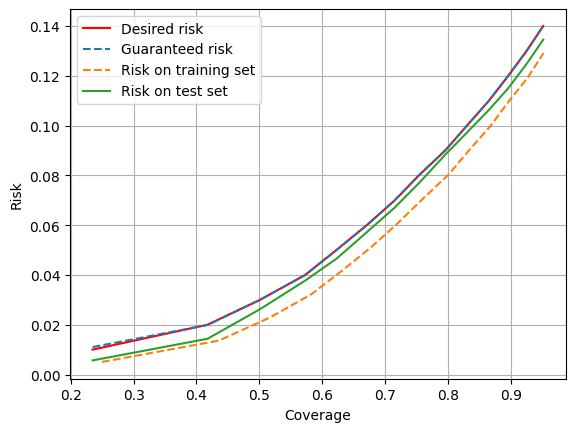

In [21]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.legend()
plt.grid()
plt.show()

### <font color = 'yellow'> SGR with __0/1 loss__ for binary classification + evolution of guarantees as 0/1 classes imbalance increases

In [22]:
binary_set = sgr_df.loc[sgr_df.y_true.isin([0,1])]
binary_set.shape[0]

5978

In [28]:
all_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(binary_set, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=2800)

    train_set = imbalanced_set.iloc[:1800]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[1000:]

    results = SGR_at_risks(train_set,test_set)
    results['proportion_1'] = proportion_1/100
    all_dfs = pd.concat([all_dfs, results]).reset_index(drop=True)

    

In [29]:
all_dfs

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage,proportion_1
0,0.01,0.015381,0.002225,0.499444,0.002230,0.498333,0.01
1,0.02,0.018951,0.005814,0.668889,0.010664,0.677222,0.01
2,0.03,0.029388,0.013463,0.742778,0.018671,0.743889,0.01
3,0.04,0.041321,0.022917,0.800000,0.030429,0.803333,0.01
4,0.05,0.050385,0.030464,0.838889,0.036818,0.845000,0.01
...,...,...,...,...,...,...,...
695,0.10,0.079071,0.056174,0.998889,0.067815,0.999444,0.50
696,0.11,0.079071,0.056174,0.998889,0.067815,0.999444,0.50
697,0.12,0.079071,0.056174,0.998889,0.067815,0.999444,0.50
698,0.13,0.079071,0.056174,0.998889,0.067815,0.999444,0.50


C:\Users\ejeme\AppData\Local\Temp\ipykernel_6876\2296751728.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blue = cm.get_cmap('Blues')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_6876\2296751728.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_viridis = cm.get_cmap('viridis')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_6876\2296751728.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_green = cm.get_cmap('Greens')
C:\Users\ejeme\AppData\L

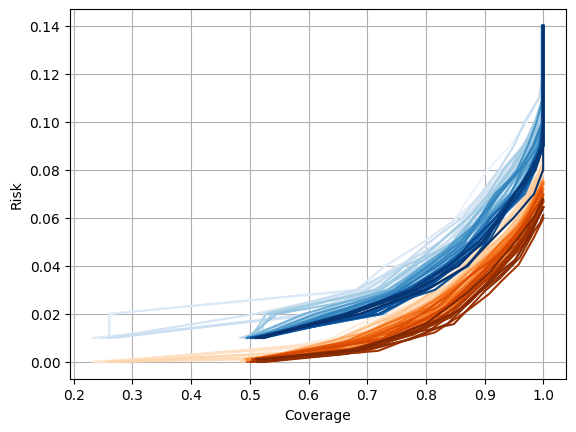

In [44]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Choose a colormap, e.g., 'viridis' or 'Blues'
cmap_blue = cm.get_cmap('Blues')
cmap_viridis = cm.get_cmap('viridis')
cmap_green = cm.get_cmap('Greens')
cmap_orange = cm.get_cmap('Oranges')

for proportion_1 in range(1,51):

    norm_value = proportion_1 / 50  # because 50 is the max
    blue,viridis,green,orange = cmap_blue(norm_value),cmap_viridis(norm_value),cmap_green(norm_value),cmap_orange(norm_value)

    results = all_dfs.loc[all_dfs.proportion_1 == proportion_1/100]
    
    plt.plot(results.test_coverage, results.desired_risk, color = blue, label = str(proportion_1))
    #plt.plot(results.test_coverage, results.risk_bound, color = viridis, label = 'Guaranteed risk')
    #plt.plot(results.train_coverage, results.train_risk, color = green, label = 'Risk on training set')
    plt.plot(results.test_coverage, results.test_risk, color = orange, label = 'Risk on test set')

plt.xlabel('Coverage')
plt.ylabel('Risk')
#plt.legend()
plt.grid()
#plt.ylim(0,0.08)
plt.show()

L'arbitrage risque/couverture est de plus en plus mauvais avec l'augmentation du déséquilibre de classe (couleur moins intense). 

Autrement dit, à couverture égale le risque d'erreur augmente quand le déséquilibre augmente.

### <font color = 'yellow'> SGR with __type {I,II} loss__ for binary classification + evolution of guarantees as 0/1 classes imbalance increases